In [1]:
import math

In [2]:
class Coor:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        # return f"Coor({self.x:.6f}, {self.y:.6f})"
        return self.toString(6)

    def __repr__(self):
        return str(self)

    def toString(self, precision=3):
        """Cast to string with chosen precision"""

        return f"Coor({self.x:.{precision}f}, {self.y:.{precision}f})"

    def __add__(self, other):
        return self.add(other)

    def __sub__(self, other):
        return self.subtract(other)

    def __neg__(self):
        return self.negate()

    def add(self, offset):
        x = self.x + offset.x
        y = self.y + offset.y

        return Coor(x, y)

    def subtract(self, offset):
        x = self.x - offset.x
        y = self.y - offset.y

        return Coor(x, y)

    def negate(self):
        x = -self.x
        y = -self.y

        return Coor(x, y)

    def scale(self, scaleFactor):
        x = self.x * scaleFactor
        y = self.y * scaleFactor

        return Coor(x, y)

    def rotate(self, theta):
        """Return the rotation of the current coor by `theta` radians counterclockwise around the origin"""

        sinTheta = math.sin(theta)
        cosTheta = math.cos(theta)
        x = self.x * cosTheta - self.y * sinTheta
        y = self.x * sinTheta + self.y * cosTheta

        # print(f"Rotate {self} by {theta} radians -> {Coor(x, y)}")

        return Coor(x, y)

    def distSquared(self, other):
        return (self.x - other.x)**2 + (self.y - other.y)**2

    def dist(self, other):
        return math.sqrt(self.distSquared(other))


In [3]:
class Ellipse:
    def __init__(self, x, y, radiusX, radiusY, rotation):
        self.center = Coor(x, y)
        self.radiusX = radiusX
        self.radiusY = radiusY
        self.rotation = rotation

    def __str__(self):
        return self.toString(6)

    def __repr__(self):
        return str(self)

    def toString(self, precision=3):
        """Cast to string with chosen precision"""

        return f"Ellipse({self.center.toString(precision)}, {self.radiusX:.{precision}f}, {self.radiusY:.{precision}f}, {self.rotation:.{precision}f})"

    def getPointAtAngle(self, alpha):
        theta = self.rotation
        sinTheta = math.sin(theta)
        cosTheta = math.cos(theta)

        sinAlpha = math.sin(alpha)
        cosAlpha = math.cos(alpha)

        rx = self.radiusX
        ry = self.radiusY

        x = self.center.x + rx*cosAlpha*cosTheta - ry*sinAlpha*sinTheta
        y = self.center.y + rx*cosAlpha*sinTheta + ry*sinAlpha*cosTheta

        return Coor(x, y)

    def pointOnEllipseInDirectionOfAnotherPoint(self, point):
        adjustedPoint = point.subtract(self.center).rotate(-self.rotation)

        thetaFromCenterToPoint = math.atan2(self.radiusX * adjustedPoint.y, self.radiusY * adjustedPoint.x)

        # TODO: try computing slope (adjusted.y / adjusted.x) and using line equation to compute point on ellipse...

        pointOnOrigEllipse = self.getPointAtAngle(thetaFromCenterToPoint)
        squaredDistToPointOnOrigEllipse = point.distSquared(pointOnOrigEllipse)
        closestPoint = pointOnOrigEllipse
        closestDistSquared = squaredDistToPointOnOrigEllipse

        # print(f"  point: {point}")
        # print(f"  adjustedPoint: {adjustedPoint}")
        # print(f"  thetaFromCenterToPoint: {thetaFromCenterToPoint}")
        # print(f"  pointOnOrigEllipse: {pointOnOrigEllipse}")
        # print(f"  closestPoint: {closestPoint}")
        # print(f"  closestDistSquared: {closestDistSquared}")

        return [closestPoint, closestDistSquared, thetaFromCenterToPoint]

    def nearestPointToAnotherPointApproximatation(self, point):
        """Compute approximate point on an ellipse closest to another point."""
        [initialPoint, initDistSquared, initTheta] = self.pointOnEllipseInDirectionOfAnotherPoint(point)

        thetaStepSize = math.pi / 100
        stepForwardDist = point.dist(self.getPointAtAngle(initTheta + thetaStepSize))
        stepBackwardDist = point.dist(self.getPointAtAngle(initTheta - thetaStepSize))

        # // Return early if initial point is best
        if (initDistSquared <= min(stepForwardDist, stepBackwardDist)):
            # // throw Error()
            return [initialPoint, initDistSquared, initTheta]

        # // Ensure thetaStepSize is in correct direction
        if (stepBackwardDist < stepForwardDist):
            thetaStepSize = -thetaStepSize
        
        # // Iterate till we find closest point
        [currPoint, currDistSquared, currTheta] = [initialPoint, initDistSquared, initTheta]
        [nextPoint, nextDistSquared, nextTheta] = [initialPoint, initDistSquared, initTheta]
        numSteps = 0

        while (nextDistSquared < currDistSquared or numSteps == 0):
            [currPoint, currDistSquared, currTheta] = [nextPoint, nextDistSquared, nextTheta]
            
            nextTheta = currTheta + thetaStepSize
            nextPoint = self.getPointAtAngle(nextTheta)
            nextDistSquared = point.distSquared(nextPoint)
            numSteps += 1
        
        # thetaStepSizeDegree = thetaStepSize * 180 / math.pi
        # initThetaDegree = initTheta * 180 / math.pi
        # // console.log(`initTheta (${initThetaDegree.toFixed(2)}) -> ${numSteps} steps of size ${thetaStepSizeDegree.toFixed(2)}`)
        
        return [currPoint, currDistSquared, currTheta]

In [ ]:
el = Ellipse(0, 0, 2, 1, 0)
# print(el)
# print(el.getPointAtAngle(0))
# print(el.getPointAtAngle(math.pi/2))
# a = Coor(1, 1)
# b = Coor(2, 3)
# print(a, b)
# print(a+b)
# print(a-b)
# print(-a)

# unit_circle = Ellipse(0, 0, 1, 1, 0)
print(el)
# print(el.nearestPointToAnotherPointApproximatation(Coor(3, 0)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(0, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(2.0, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(1.8, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(1.6, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(1.4, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(1.2, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(1.0, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(0.8, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(0.6, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(0.4, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(0.2, 2)))
# print(el.nearestPointToAnotherPointApproximatation(Coor(0.0, 2)))

for coor in [
  (3, 0), (0, 2),
  (2.0, 2), (1.8, 2), (1.6, 2), (1.4, 2), (1.2, 2), (1.0, 2),
  (0.8, 2), (0.6, 2), (0.4, 2), (0.2, 2), (0.0, 2)
]:
    d = round(el.nearestPointToAnotherPointApproximatation(Coor(*coor))[1], 3)
    print(f"d = Number(el.nearestPointToAnotherPointApproximatation(new Coor{coor})[1].toFixed(4));\nconsole.log(`{coor}: Python {d} | JavaScript: ""${d} | Diff: ${(Math.abs("f"{d}"" - d)).toFixed(4)}`)")


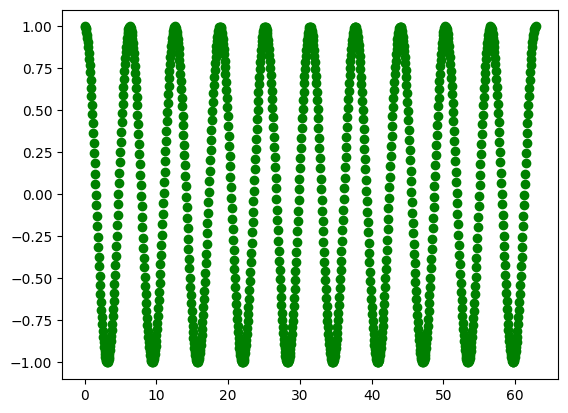

In [40]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

X = np.linspace(0, 20*np.pi, 1000)
Y = np.cos(X)

fig, ax = plt.subplots()
ax.scatter(X, Y, color='green')
plt.show()